In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import mlflow

# !pip install mlflow

In [140]:
mlflow.start_run()

<ActiveRun: >

In [141]:
mlflow.set_experiment("loan-status")

mlflow.set_tag("mlflow.runName", "third-run")

In [142]:
train_df = pd.read_csv('loan.csv')

In [143]:
train_df.head(5)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [144]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 83.4 KB


In [145]:
train_df.isna().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [146]:
train_df.dropna(inplace=True)
train_df.isna().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [147]:
train_df['Gender']=train_df['Gender'].map({'Male':0,'Female':1})
train_df['Married']=train_df['Married'].map({'No':0,'Yes':1})
train_df['Loan_Status']=train_df['Loan_Status'].map({'N':0,'Y':1}) 

train_df.info()

<class 'pandas.DataFrame'>
Index: 480 entries, 1 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            480 non-null    str    
 1   Gender             480 non-null    int64  
 2   Married            480 non-null    int64  
 3   Dependents         480 non-null    str    
 4   Education          480 non-null    str    
 5   Self_Employed      480 non-null    str    
 6   ApplicantIncome    480 non-null    int64  
 7   CoapplicantIncome  480 non-null    float64
 8   LoanAmount         480 non-null    float64
 9   Loan_Amount_Term   480 non-null    float64
 10  Credit_History     480 non-null    float64
 11  Property_Area      480 non-null    str    
 12  Loan_Status        480 non-null    int64  
dtypes: float64(4), int64(4), str(5)
memory usage: 65.3 KB


In [148]:
feature_columns=['Gender','Married','ApplicantIncome','LoanAmount','Credit_History']

X=train_df[feature_columns]
y=train_df['Loan_Status']

mlflow.log_param("feature_columns", feature_columns)

print(X.shape)
print(y.shape)

(480, 5)
(480,)


In [149]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [150]:
from sklearn.ensemble import RandomForestClassifier

max_depth = 4
model = RandomForestClassifier(max_depth=max_depth, random_state=42)

model.fit(X_train, y_train)

mlflow.log_param("max_depth", max_depth)

4

In [151]:
from sklearn.metrics import accuracy_score

pred_val = model.predict(X_val)
val_accuracy = accuracy_score(y_val, pred_val)

mlflow.log_metric("val_accuracy", val_accuracy)

In [152]:
pred_train = model.predict(X_train)
train_acc = accuracy_score(y_train, pred_train)

mlflow.log_metric("train_accuracy", train_acc)

In [153]:
mlflow.end_run()

In [154]:
with mlflow.start_run():

    max_depth = 6
    model = RandomForestClassifier(max_depth=max_depth, random_state=42)
    model.fit(X_train, y_train)

    mlflow.log_param("max_depth", max_depth)

    pred_val = model.predict(X_val)
    val_accuracy = accuracy_score(y_val, pred_val)

    mlflow.log_metric("val_accuracy", val_accuracy)

    pred_train = model.predict(X_train)
    train_acc = accuracy_score(y_train, pred_train)

    mlflow.log_metric("train_accuracy", train_acc)

    mlflow.sklearn.log_model(model, "randomforest-model")

    mlflow.log_artifact("loan.csv")

2026/07/03 06:58:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [155]:
def mlflow_runs(n_est,max_dep,i):
    with mlflow.start_run():

        model_rf = RandomForestClassifier(n_estimators=n_est, max_depth=max_dep, random_state=5)
        model_rf.fit(X_train, y_train)

        pred_val = model_rf.predict(X_val)
        val_acc=accuracy_score(y_val, pred_val)

        pred_train = model_rf.predict(X_train)
        train_acc=accuracy_score(y_train, pred_train)

        run="hyperparameter_run_"+str(i)
        mlflow.set_tag('mlflow.runName',run)
        mlflow.log_param('n_estimators',n_est)
        mlflow.log_param('max_depth',max_dep)
        mlflow.log_metric('val_acc',val_acc)
        mlflow.log_metric('train_acc',train_acc)
        mlflow.set_tag('data file','data_new.csv')

        mlflow.sklearn.log_model(model_rf, "model")


mlflow_runs(10,2,1)
mlflow_runs(20,2,2)
mlflow_runs(40,2,3)
mlflow_runs(10,4,4)
mlflow_runs(20,4,5)
mlflow_runs(40,4,6)
mlflow_runs(10,8,7)
mlflow_runs(20,8,8)
mlflow_runs(40,8,9)
[1, 2, 5, 10 , 20]


2026/07/03 06:58:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/03 06:59:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/03 06:59:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/03 06:59:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/03 06:59:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/03 06:59:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/03 06:59:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/03 06:59:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/03 07:00:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[1, 2, 5, 10, 20]

2026/07/03 07:41:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


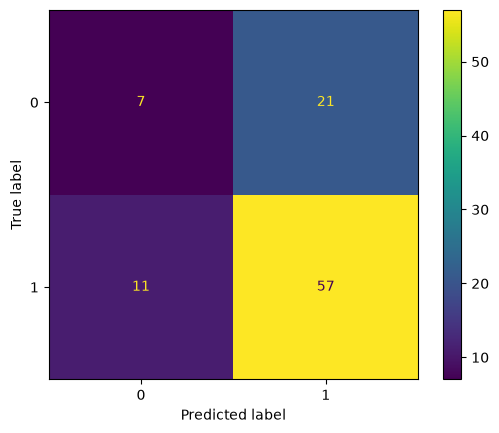

In [160]:
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

with mlflow.start_run():
    knn_model= KNeighborsClassifier(n_neighbors=5)
    knn_model.fit(X_train, y_train)

    pred_val = knn_model.predict(X_val)
    val_acc=accuracy_score(y_val, pred_val)

    pred_train = knn_model.predict(X_train)
    train_acc=accuracy_score(y_train, pred_train)

    run="KNN"
    mlflow.set_tag('mlflow.runName',run)
    mlflow.log_param('neighbors',5)
    mlflow.log_metric('val_acc',val_acc)
    mlflow.log_metric('train_acc',train_acc)
    mlflow.set_tag('data file','data_new.csv')

    cm=ConfusionMatrixDisplay.from_predictions( y_val,pred_val)
    cm.figure_.savefig('confusion_mat.png')
    mlflow.log_artifact('confusion_mat.png')

mlflow.sklearn.log_model(
    sk_model=knn_model,
    name="model",
    serialization_format="pickle"
)

In [159]:
import mlflow
print(mlflow.__version__)

3.14.0
